In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)

#### Monte Carlo Simulation, Power Analysis, and Robustness Evaluation

In [3]:
# Simulation parameters

n_simulations = 200

n_participants = 40
n_trials = 30

population_intercept = 650
condition_effect = 35

participant_sd = 50
residual_sd = 30

alpha = 0.05

In [9]:
# Running Monte Carlo simulation.

significant_results = []

estimated_effects = []

for simulation in range(n_simulations):

    data = []

    participant_intercepts = np.random.normal(
        population_intercept,
        participant_sd,
        n_participants,
    )

    for participant in range(n_participants):

        intercept = participant_intercepts[participant]

        for condition in ["Control", "Experimental"]:

            for trial in range(n_trials):

                x = 0 if condition == "Control" else 1

                reaction_time = (
                    intercept
                    + condition_effect * x
                    + np.random.normal(
                        0,
                        residual_sd,
                    )
                )

                data.append(
                    [
                        participant,
                        condition,
                        reaction_time,
                    ]
                )

    simulated_data = pd.DataFrame(
        data,
        columns=[
            "participant",
            "condition",
            "reaction_time",
        ],
    )

    model = smf.mixedlm(
        "reaction_time ~ C(condition)",
        data=simulated_data,
        groups="participant",
    )

    results = model.fit()

    p_value = results.pvalues["C(condition)[T.Experimental]"]

    estimate = results.params["C(condition)[T.Experimental]"]

    significant_results.append(p_value < alpha)

    estimated_effects.append(estimate)

In [10]:
# Estimating statistical power.

power = np.mean(significant_results)

print("Estimated power:", round(power, 3))

# Robustness statistics

estimated_effects = np.array(
    estimated_effects
)

print(
    "\nMean estimated effect:",
    round(estimated_effects.mean(), 2),
)

print(
    "Standard deviation:",
    round(estimated_effects.std(), 2),
)

print(
    "Minimum estimate:",
    round(estimated_effects.min(), 2),
)

print(
    "Maximum estimate:",
    round(estimated_effects.max(), 2),
)

Estimated power: 1.0

Mean estimated effect: 34.97
Standard deviation: 1.16
Minimum estimate: 31.68
Maximum estimate: 38.84


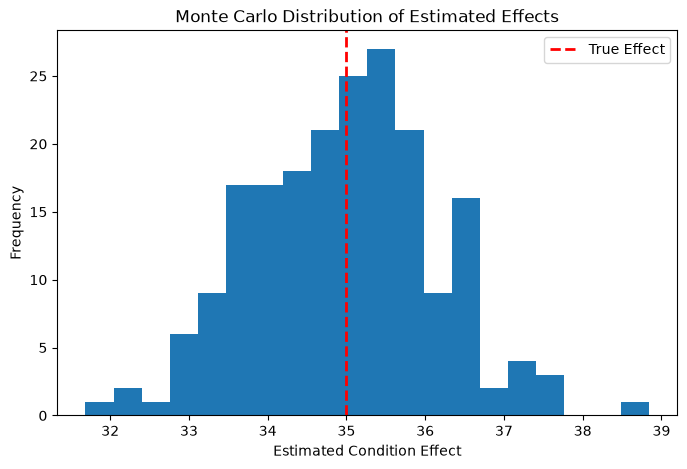

In [11]:
# Distribution of estimated effects.

plt.figure(figsize=(8, 5))

plt.hist(
    estimated_effects,
    bins=20,
)

plt.axvline(
    condition_effect,
    color="red",
    linestyle="--",
    linewidth=2,
    label="True Effect",
)

plt.xlabel("Estimated Condition Effect")
plt.ylabel("Frequency")
plt.title("Monte Carlo Distribution of Estimated Effects")

plt.legend()

plt.show()